In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
 
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
df = pd.read_csv(r"C:\Users\User\OneDrive\UOA OneDrive\Thesis\V2\Article\FREELANCE\Master Data\ML\District_MasterML.csv")

In [3]:
COL_STATE = 'State'
COL_DISTRICT = 'District'
COL_YEAR = 'Year'
COL_PROPTYPE = 'PropertyType'
COL_INCOME = 'MedianIncome'
COL_PRICE = 'MedianPrice'
COL_PIR = 'PriceIncomeRatio'
 
df.head()

,StateID,State,StateCode,DistrictCode,Year,District,MedianIncome,PropertyType,MeanPrice,MedianPrice,MedianPrice2015,PriceIndex2015,PriceIncomeRatio
0,1,Johor,JHR,101,2015,Batu Pahat,5142.0,Cluster House,432484.0,485125.0,485125.0,100.0,7.86
1,1,Johor,JHR,101,2015,Batu Pahat,5142.0,Condominium/Apartment,293122.0,260000.0,260000.0,100.0,4.21
2,1,Johor,JHR,101,2015,Batu Pahat,5142.0,Detached House,477386.0,330000.0,330000.0,100.0,5.35
3,1,Johor,JHR,101,2015,Batu Pahat,5142.0,Flat,87857.0,82000.0,82000.0,100.0,1.33
4,1,Johor,JHR,101,2015,Batu Pahat,5142.0,Low-Cost Flat,NaN,NaN,NaN,NaN,NaN


In [4]:
# Build features per district

latest_year = df[COL_YEAR].max()
first_year = df[COL_YEAR].min()

if 'All' in df[COL_PROPTYPE].unique():
    base = df[df[COL_PROPTYPE] == 'All'].copy()
else:
    base = (df.groupby([COL_STATE, COL_DISTRICT, COL_YEAR], as_index=False)
              .agg({COL_INCOME: 'median', COL_PRICE: 'median', COL_PIR: 'median'}))
    
# Snapshot at the latest year
latest = base[base[COL_YEAR] == latest_year][[COL_STATE, COL_DISTRICT, COL_INCOME, COL_PRICE, COL_PIR]]
latest = latest.rename(columns={COL_INCOME: 'Income', COL_PRICE: 'Price', COL_PIR: 'PIR'})
 
# Price growth rate (CAGR) from first year to latest year, per district
first = base[base[COL_YEAR] == first_year][[COL_DISTRICT, COL_PRICE]].rename(columns={COL_PRICE: 'Price_first'})
n_years = latest_year - first_year
 
growth = latest.merge(first, on=COL_DISTRICT, how='left')
growth['PriceGrowthCAGR'] = (growth['Price'] / growth['Price_first']) ** (1 / n_years) - 1
 
features = growth[[COL_STATE, COL_DISTRICT, 'Income', 'Price', 'PIR', 'PriceGrowthCAGR']].dropna()
print(f"{len(features)} districts with complete data")
features.head()

124 districts with complete data


,State,District,Income,Price,PIR,PriceGrowthCAGR
0,Johor,Batu Pahat,7555.0,296750.0,3.27,0.010904
1,Johor,Johor Bahru,8977.0,445000.0,4.13,0.041263
2,Johor,Kluang,6158.0,270000.0,3.65,0.003781
3,Johor,Kota Tinggi,6284.0,325000.0,4.31,0.055147
4,Johor,Kulai,8406.0,210000.0,2.08,0.002413


In [5]:
# Standardize features
feature_cols = ['Income', 'Price', 'PIR', 'PriceGrowthCAGR']
X = features[feature_cols].values
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^

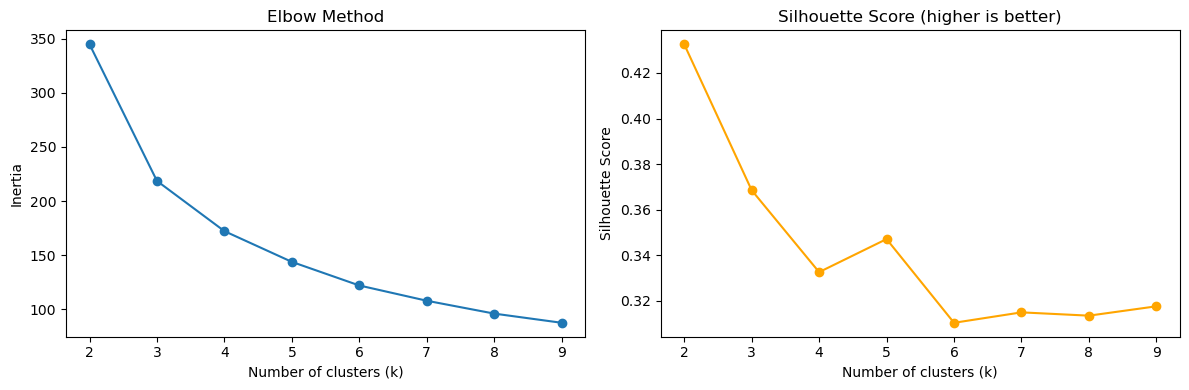

Best k by silhouette score: 2


In [6]:
# Find a reasonable number of clusters

inertias = []
silhouettes = []
k_range = range(2, 10)
 
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
 
axes[1].plot(list(k_range), silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette Score (higher is better)')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()
 
best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Best k by silhouette score: {best_k}")

In [7]:
# Fit K-Means with the chosen k
# While 2 clusters produced the highest silhouette score; however, these clusters primarily separated on urban/rural scale rather than affordability. Hence, I chose 4 clusters for greater interpretability.

chosen_k = 4
 
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
features['Cluster'] = kmeans.fit_predict(X_scaled)
 
features['Cluster'].value_counts().sort_index()

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Cluster
0    57
1    19
2    28
3    20
Name: count, dtype: int64

In [8]:
# Profile each cluster
cluster_profile = features.groupby('Cluster')[feature_cols].mean().round(2)
cluster_profile['n_districts'] = features['Cluster'].value_counts().sort_index()
cluster_profile

,Income,Price,PIR,PriceGrowthCAGR,n_districts
Cluster,,,,,
0,5133.91,254708.72,4.23,0.03,57
1,11281.79,526402.63,4.03,0.01,19
2,4361.73,358258.57,7.01,0.06,28
3,5293.20,171792.50,2.84,-0.04,20


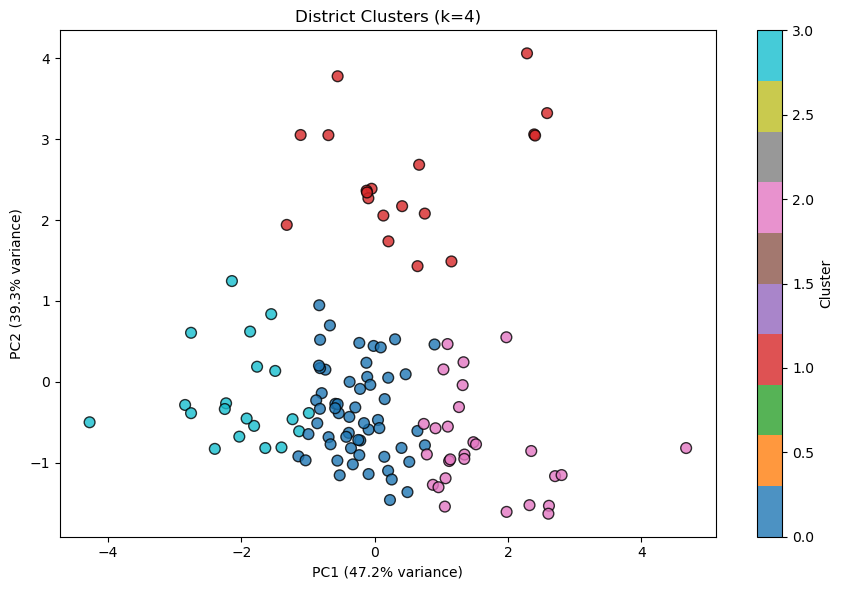

In [9]:
# Visualize clusters in 2D (via PCA)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
 
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=features['Cluster'], cmap='tab10', s=60, edgecolor='k', alpha=0.8)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'District Clusters (k={chosen_k})')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()
 
# %% [markdown]

In [10]:
# See which districts fall in each cluster

for c in sorted(features['Cluster'].unique()):
    print(f"\n=== Cluster {c} ===")
    print(features[features['Cluster']==c][[COL_STATE, COL_DISTRICT, 'Income', 'Price', 'PIR', 'PriceGrowthCAGR']]
          .sort_values('PIR', ascending=False).to_string(index=False))


=== Cluster 0 ===
          State               District  Income    Price   PIR  PriceGrowthCAGR
       Kelantan                   Jeli  3008.0 212250.0 5.880         0.028984
       Kelantan              Pasir Mas  3591.0 230000.0 5.340         0.000109
          Perak          Kuala Kangsar  3977.0 250000.0 5.240         0.029494
          Kedah                  Kulim  4498.0 280000.0 5.190         0.064404
        Sarawak                 Betong  3418.0 211250.0 5.150         0.065036
          Sabah               Beaufort  4070.0 250000.0 5.120         0.057822
          Sabah               Keningau  4801.0 284722.0 4.945         0.021573
Negeri Sembilan                 Tampin  4367.0 258500.0 4.930         0.052478
          Perak           Larut Matang  4843.0 285500.0 4.910         0.062302
   Pulau Pinang Seberang Perai Selatan  6822.0 400000.0 4.890         0.051248
         Pahang                  Pekan  4344.0 255000.0 4.890         0.000788
          Kedah                 B